In [1]:
import time
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import gmean
from statistics import mean
from datetime import date
from yfetch import get_stock_history

ucits = pd.read_csv('data/ucits.csv')
symbol_map = ucits.set_index('Symbol')['Name'].to_dict()
symbol_map.update({
  'BRK-B': 'Berkshire Hathaway'
})

In [2]:
hm = {}
for symbol, name in symbol_map.items():
    history = get_stock_history(symbol, interval='1wk', cache_days=3)
    hm[symbol] = history
    print(f'{symbol}: {len(history)}w ({name})')

Fetched history for 10A2.BE (1 rows)
10A2.BE: 1w (AIS-Amundi MSCI EUROPE Val.FA.N)
4MMR.DE: 71w (Global X Defence Tech UCITS ETF USD Accumulating)
Fetched history for DXSA.DE (261 rows)
DXSA.DE: 261w (Xtrackers Euro Stoxx Quality Dividend UCITS ETF)
Fetched history for EHDV.DE (261 rows)
EHDV.DE: 261w (Invesco EURO STOXX High Dividend Low Volatility UCITS ETF)
EHF1.DE: 261w (Amundi Index Solutions - Amundi MSCI Europe High Dividend Factor UCITS ETF-C)
ESIF.DE: 261w (iShares MSCI Europe Financials Sector UCITS ETF)
Fetched history for EXV1.DE (261 rows)
EXV1.DE: 261w (iShares STOXX Europe 600 Banks UCITS ETF (DE))
Fetched history for F702.DE (261 rows)
F702.DE: 261w (Amundi Multi-Asset Portfolio Defensive UCITS ETF Dist)
Fetched history for FLXD.DE (261 rows)
FLXD.DE: 261w (Franklin European Quality Dividend UCITS ETF)
JEDI.DE: 187w (VanEck Space Innovators UCITS ETF)
Fetched history for LGWS.DE (83 rows)
LGWS.DE: 83w (Amundi MSCI EMU Value Factor ETF Distribution)
Fetched history for L

In [3]:
def crunch(history_weeks, weeks=52):
    assert history_weeks > weeks
    rows = []
    for symbol, history in hm.items():
        if len(history) < history_weeks:
            continue    
        history = history.tail(history_weeks)
        sma = history.Close.rolling(window=13).mean().dropna() # 3 months smoothing
        cagr = (sma.iloc[-1] / sma.iloc[0]) ** (weeks / len(sma)) - 1 # annualized change
        changes = history.Close.pct_change(periods=weeks).dropna()
        gmean_change = gmean(1 + changes) - 1 # geometric mean of changes
        median_change = changes.median()
        std = changes.std()
        rows.append({
            'symbol': symbol,
            'name': symbol_map.get(symbol),
            'CAGR': cagr,
            'median change': median_change,
            'gmean change': gmean_change,
            'std': std,
            'gmean/std': gmean_change / std,
            'median/std': median_change / std,
        })
    
    df = pd.DataFrame(rows).sort_values(by='gmean/std', ascending=False).reset_index(drop=True)
    f = f'data/ucits-{weeks}w-over-{history_weeks}w.csv'
    df.to_csv(f, index=False)
    print(f'Saved to {f} ({len(df)}/{len(hm)})')
    
    for col in ['CAGR', 'median change', 'gmean change', 'std']:
      df[col] = df[col].map('{:.2%}'.format)
    df['gmean/std'] = df['gmean/std'].map('{:.2f}'.format)
    df['median/std'] = df['median/std'].map('{:.2f}'.format)
    display(df)


In [10]:
crunch(261, 52) # 1y over 5y

Saved to data/ucits-52w-over-261w.csv (17/23)


,symbol,name,CAGR,median change,gmean change,std,gmean/std,median/std
0,VDIV.DE,VanEck Morningstar Developed Markets Dividend ...,17.09%,17.20%,16.28%,6.93%,2.35,2.48
1,EHF1.DE,Amundi Index Solutions - Amundi MSCI Europe Hi...,11.64%,11.60%,11.01%,5.93%,1.86,1.96
2,FLXD.DE,Franklin European Quality Dividend UCITS ETF,11.60%,11.40%,10.85%,8.27%,1.31,1.38
3,ESIF.DE,iShares MSCI Europe Financials Sector UCITS ETF,20.84%,22.86%,19.45%,15.25%,1.28,1.50
4,EXV1.DE,iShares STOXX Europe 600 Banks UCITS ETF (DE),29.90%,31.18%,27.23%,21.46%,1.27,1.45
5,BRK-B,Berkshire Hathaway,15.60%,18.60%,15.71%,12.76%,1.23,1.46
6,LYBK.DE,Amundi Euro Stoxx Banks UCITS ETF Acc,32.58%,34.80%,29.39%,25.88%,1.14,1.34
7,SPPY.DE,SPDR S&P 500 Leaders UCITS ETF,15.08%,10.94%,12.63%,13.07%,0.97,0.84
8,QDVE.DE,iShares S&P 500 Information Technology Sector ...,21.73%,19.90%,18.91%,20.50%,0.92,0.97
9,XLKS.MI,Invesco Technology S&P US Select Sector UCITS ETF,23.20%,20.89%,20.16%,22.02%,0.92,0.95


In [5]:
crunch(156, 52) # 1y over 3y

Saved to data/ucits-52w-over-156w.csv (19/23)


,symbol,name,CAGR,median change,gmean change,std,gmean/std,median/std
0,F702.DE,Amundi Multi-Asset Portfolio Defensive UCITS E...,9.53%,10.06%,10.21%,2.47%,4.13,4.06
1,VDIV.DE,VanEck Morningstar Developed Markets Dividend ...,16.39%,18.08%,17.71%,4.54%,3.90,3.98
2,ESIF.DE,iShares MSCI Europe Financials Sector UCITS ETF,28.04%,32.77%,31.50%,8.64%,3.64,3.79
3,FLXD.DE,Franklin European Quality Dividend UCITS ETF,15.08%,18.37%,17.47%,4.81%,3.63,3.82
4,EHF1.DE,Amundi Index Solutions - Amundi MSCI Europe Hi...,13.05%,14.28%,14.20%,3.96%,3.59,3.61
5,EXV1.DE,iShares STOXX Europe 600 Banks UCITS ETF (DE),39.67%,42.44%,42.85%,15.91%,2.69,2.67
6,DXSA.DE,Xtrackers Euro Stoxx Quality Dividend UCITS ETF,17.71%,17.99%,18.59%,6.95%,2.68,2.59
7,LYBK.DE,Amundi Euro Stoxx Banks UCITS ETF Acc,43.44%,44.82%,46.92%,19.46%,2.41,2.30
8,EHDV.DE,Invesco EURO STOXX High Dividend Low Volatilit...,17.71%,19.32%,19.64%,8.15%,2.41,2.37
9,SPPE.DE,SPDR S&P 500 UCITS ETF EUR Acc H,19.61%,18.92%,19.05%,8.12%,2.35,2.33


In [6]:
crunch(104, 26) # 6m over 2y

Saved to data/ucits-26w-over-104w.csv (19/23)


,symbol,name,CAGR,median change,gmean change,std,gmean/std,median/std
0,ESIF.DE,iShares MSCI Europe Financials Sector UCITS ETF,15.71%,14.87%,15.83%,6.30%,2.51,2.36
1,FLXD.DE,Franklin European Quality Dividend UCITS ETF,9.00%,8.99%,9.18%,3.88%,2.37,2.32
2,EXV1.DE,iShares STOXX Europe 600 Banks UCITS ETF (DE),22.74%,22.63%,22.38%,10.62%,2.11,2.13
3,F702.DE,Amundi Multi-Asset Portfolio Defensive UCITS E...,5.20%,4.90%,5.08%,2.43%,2.09,2.01
4,VDIV.DE,VanEck Morningstar Developed Markets Dividend ...,8.95%,7.67%,8.59%,4.34%,1.98,1.77
5,EHF1.DE,Amundi Index Solutions - Amundi MSCI Europe Hi...,7.08%,7.74%,6.69%,3.39%,1.97,2.28
6,LYBK.DE,Amundi Euro Stoxx Banks UCITS ETF Acc,24.24%,26.48%,24.20%,13.80%,1.75,1.92
7,JEDI.DE,VanEck Space Innovators UCITS ETF,33.52%,35.69%,35.44%,21.66%,1.64,1.65
8,EHDV.DE,Invesco EURO STOXX High Dividend Low Volatilit...,10.87%,9.82%,10.93%,7.00%,1.56,1.40
9,DXSA.DE,Xtrackers Euro Stoxx Quality Dividend UCITS ETF,9.63%,8.47%,9.59%,6.80%,1.41,1.25


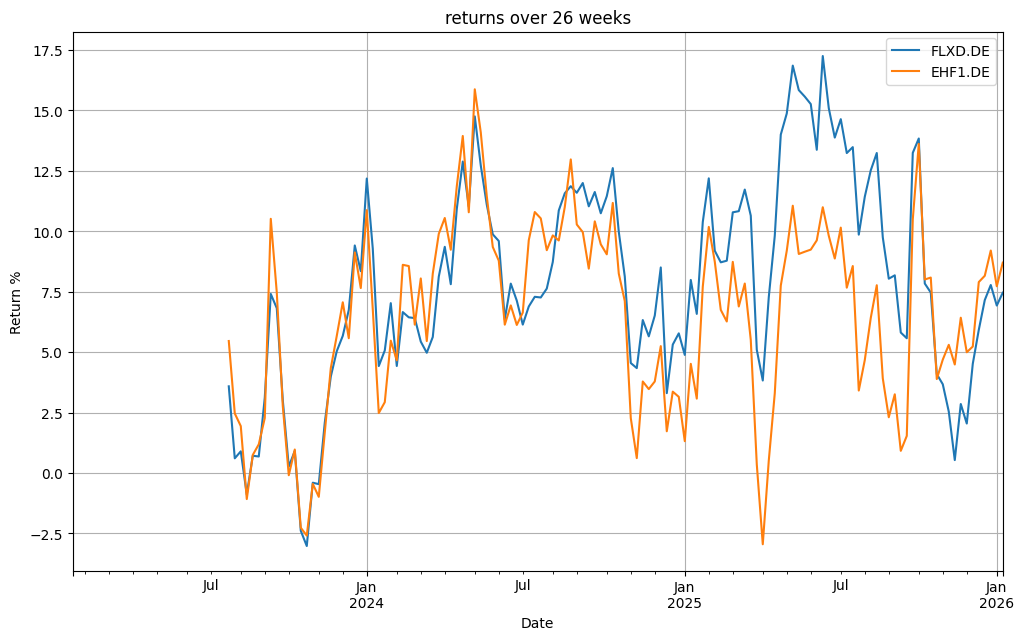

In [7]:
window_weeks = 26
df = pd.DataFrame()
for symbol in [
    # 'FLXD.DE','VDIV.DE','EHF1.DE','EHDV.DE','DXSA.DE'
    'FLXD.DE','EHF1.DE'
    ]:
    history = hm[symbol].tail(156)
    df[symbol] = history.Close.pct_change(periods=window_weeks) * 100

df.plot(figsize=(12,7))
plt.title(f'returns over {window_weeks} weeks')
plt.xlabel('Date')
plt.ylabel('Return %')
plt.legend()
plt.grid()
plt.show()

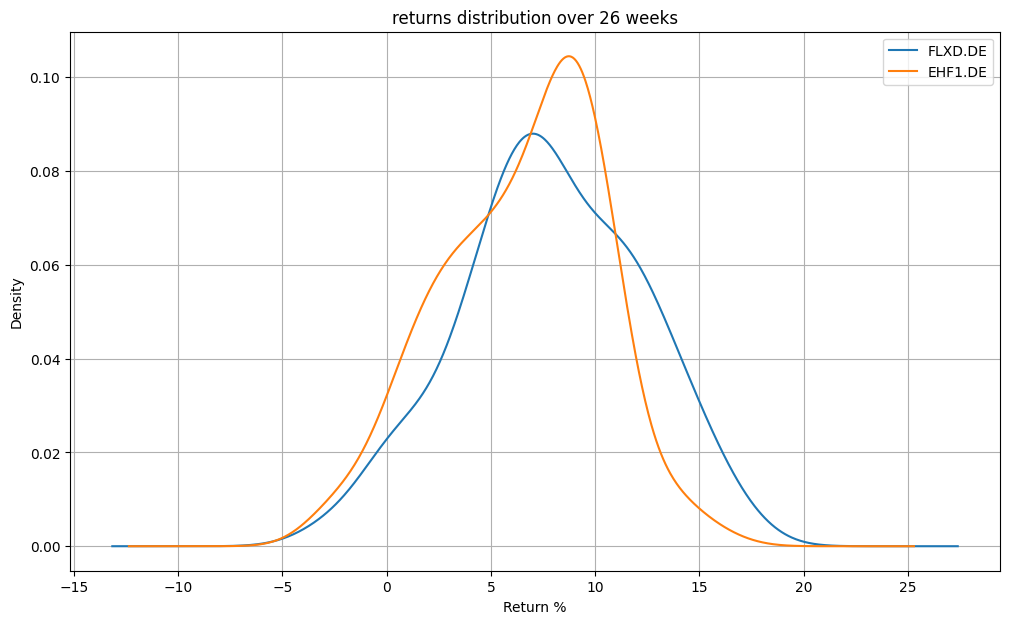

In [8]:
df.plot.kde(figsize=(12,7))
plt.title(f'returns distribution over {window_weeks} weeks')
plt.xlabel('Return %')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['VDIV.DE'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Histogram of Returns')
plt.xlabel('Return %')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

KeyError: 'VDIV.DE'

<Figure size 1000x600 with 0 Axes>